In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv(
    "career_recommendation_dataset_1000.csv"
)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

Dataset loaded successfully
Dataset shape: (1000, 55)


In [7]:
y = df["target_career"]

In [8]:
drop_columns = [
    "profile_id",
    "full_name",
    "email",
    "target_career",
    "compare_career"
]
X = df.drop(columns=drop_columns)

In [9]:
X = pd.get_dummies(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=100,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 800
Testing records: 200


In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=100
)



In [12]:
model.fit(X_train, y_train)

print("Model training completed")


Model training completed


In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy)



Model Accuracy:
0.71


In [15]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
                        precision    recall  f1-score   support

      Business Analyst       0.83      0.67      0.74        15
        Cloud Engineer       0.67      0.67      0.67        18
 Cybersecurity Analyst       0.57      0.75      0.65        16
          Data Analyst       0.60      0.60      0.60        15
        Data Scientist       0.65      0.69      0.67        16
Database Administrator       0.88      0.54      0.67        13
       DevOps Engineer       0.54      0.65      0.59        20
           ML Engineer       0.62      0.33      0.43        15
           QA Engineer       0.77      0.85      0.81        20
    Software Developer       0.72      0.72      0.72        18
        UI/UX Designer       0.89      0.94      0.92        18
         Web Developer       0.89      1.00      0.94        16

              accuracy                           0.71       200
             macro avg       0.72      0.70      0.70       200
          weig

In [17]:
model_data = {
    "model": model,
    "feature_columns": X.columns.tolist()
}

joblib.dump(
    model_data,
    "career_model.pkl"
)

print("\nModel saved successfully as career_model.pkl")


Model saved successfully as career_model.pkl


In [18]:
from google.colab import files

files.download("career_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import joblib

model_data = joblib.load("career_model.pkl")

model = model_data["model"]
feature_columns = model_data["feature_columns"]

print("Model loaded successfully!")
print(type(model))

Model loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [20]:
print(model)

RandomForestClassifier(n_estimators=200, random_state=100)


In [21]:
sample_user = df.iloc[[0]].copy()

actual_career = sample_user["target_career"].iloc[0]

sample_user = sample_user.drop(
    columns=[
        "profile_id",
        "full_name",
        "email",
        "target_career",
        "compare_career"
    ]
)

sample_user = pd.get_dummies(sample_user)

sample_user = sample_user.reindex(
    columns=X.columns,
    fill_value=0
)

predicted_career = model.predict(sample_user)[0]

print("Actual Career:", actual_career)
print("Predicted Career:", predicted_career)

Actual Career: QA Engineer
Predicted Career: QA Engineer


In [23]:
import pandas as pd

requirements = pd.read_csv("career_requirements.csv")

print("Second dataset loaded successfully!")
display(requirements.head())

Second dataset loaded successfully!


,career,skill,importance,minimum_level
0,Software Developer,AWS,1,0
1,Software Developer,Business Analysis,1,0
2,Software Developer,C++,4,2
3,Software Developer,CSS,1,0
4,Software Developer,Communication,1,0


In [24]:
career_info = requirements[
    requirements["career"] == predicted_career
]

display(career_info)

,career,skill,importance,minimum_level
330,QA Engineer,AWS,1,0
331,QA Engineer,Business Analysis,1,0
332,QA Engineer,C++,1,0
333,QA Engineer,CSS,1,0
334,QA Engineer,Communication,1,0
335,QA Engineer,Cybersecurity,1,0
336,QA Engineer,DSA,1,0
337,QA Engineer,Database Management,1,0
338,QA Engineer,Docker,1,0
339,QA Engineer,Excel,1,0


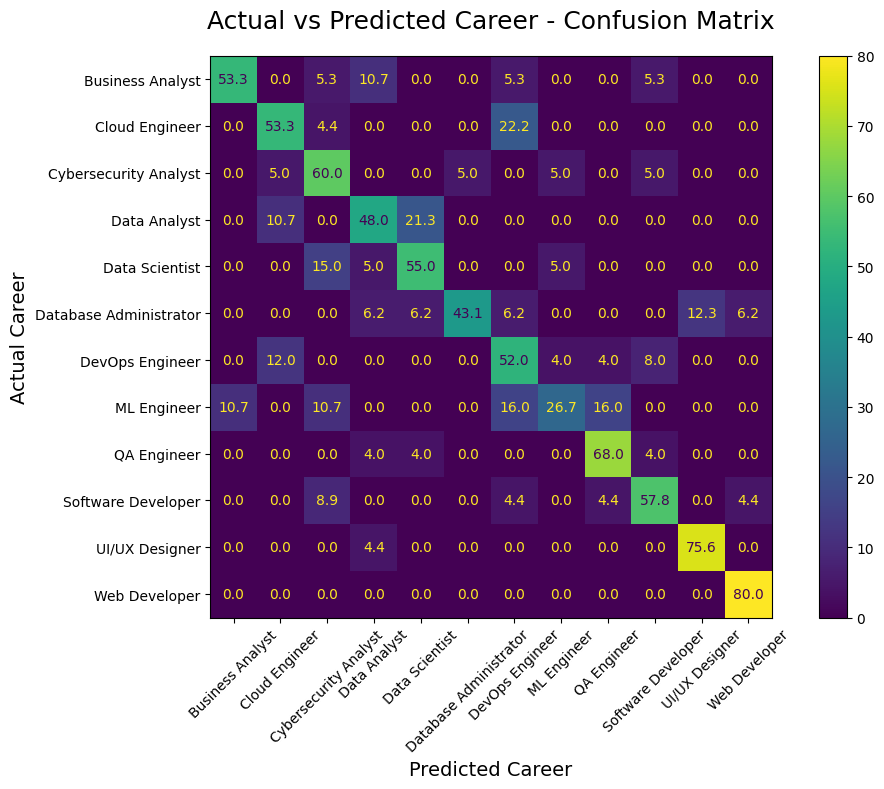

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Get career names
labels = sorted(y_test.unique())
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
# Convert to percentages
cm_percentage = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 80
# Create graph
fig, ax = plt.subplots(figsize=(11, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percentage,
    display_labels=labels
)

disp.plot(
    ax=ax,
    values_format=".1f",
    xticks_rotation=45,
    colorbar=True
)

plt.title(
    "Actual vs Predicted Career - Confusion Matrix",
    fontsize=18,
    pad=20
)

plt.xlabel("Predicted Career", fontsize=14)
plt.ylabel("Actual Career", fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()